In [ ]:
!unzip "/content/archive (2).zip" -d /content

Archive:  /content/archive (2).zip
  inflating: /content/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/Bronchial/P10BronchialSc_46.wav  
  inflating: /content/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/Bronchial/P10BronchialSc_48.wav  
  inflating: /content/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/Bronchial/P10BronchialSc_50.wav  
  inflating: /content/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/Bronchial/P10BronchialTc_47.wav  
  inflating: /content/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/Bronchial/P10BronchialTc_49.wav  
  inflating: /content/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/Bronchial/P11BronchialSc_52.wav  
  inflating: /content/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/Bronchial/P11BronchialSc_54.wav  
  inflating: /content/Asthma Detection Dataset Version 2/Asthma Detection Dataset V

In [ ]:
##############################################################################
# 1) IMPORTS AND INITIAL SETUP
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import seaborn as sns
import pandas as pd

# For splitting dataset and model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import PCA

# For evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Deep learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout,
    Bidirectional, Attention, Input, LayerNormalization
)

In [ ]:
!pip install shap

In [ ]:
##############################################################################
# NEW: IMPORTS FOR DATA AUGMENTATION AND EXPLAINABILITY (SHAP)
##############################################################################
import random
# If running locally or on some platforms, uncomment to install shap:

import shap

In [ ]:
##############################################################################
# 2) DATASET PATH
##############################################################################
# NOTE: This path should point to your Asthma Detection Dataset Version 2
dataset_path = '/content/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2'

# The five categories/folders we have in the dataset
categories = ['Bronchial', 'pneumonia', 'asthma', 'healthy', 'copd']

# Print out the list of categories
print("Categories:", categories)


Categories: ['Bronchial', 'pneumonia', 'asthma', 'healthy', 'copd']


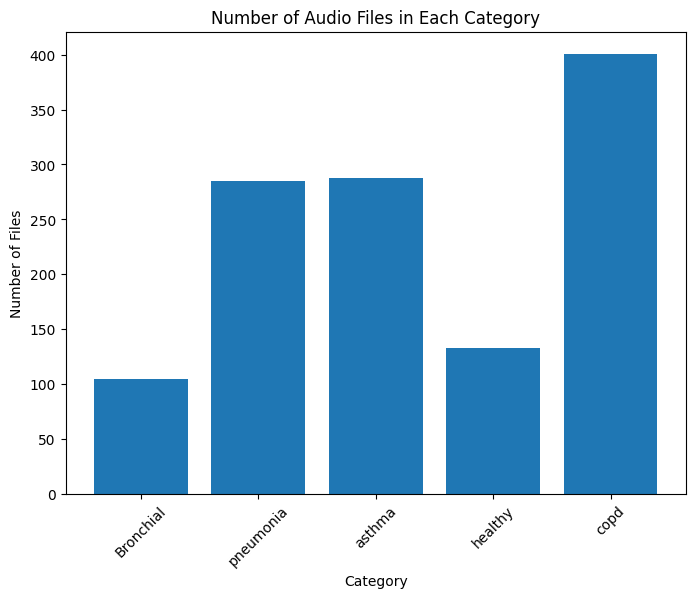

In [ ]:
##############################################################################
# 3) BAR CHART: NUMBER OF AUDIO FILES IN EACH CATEGORY
##############################################################################
# Count how many .wav files exist in each category folder
category_counts = {
    category: len([
        f for f in os.listdir(os.path.join(dataset_path, category))
        if f.endswith('.wav')
    ])
    for category in categories
}

# Plot a bar chart of category counts
plt.figure(figsize=(8, 6))
plt.bar(category_counts.keys(), category_counts.values())
plt.xlabel('Category')
plt.ylabel('Number of Files')
plt.title('Number of Audio Files in Each Category')
plt.xticks(rotation=45)
plt.show()

In [ ]:
##############################################################################
# 4) TABLE: NUMBER OF AUDIO FILES IN EACH CATEGORY
##############################################################################
# Create a PrettyTable to show the category counts
table = PrettyTable()
table.field_names = ["Category", "Number of Audio Files"]
for category, count in category_counts.items():
    table.add_row([category, count])

print("Number of Audio Files in Each Category:")
print(table)


Number of Audio Files in Each Category:
+-----------+-----------------------+
|  Category | Number of Audio Files |
+-----------+-----------------------+
| Bronchial |          104          |
| pneumonia |          285          |
|   asthma  |          288          |
|  healthy  |          133          |
|    copd   |          401          |
+-----------+-----------------------+



=== Waveform Examples for Each Category ===


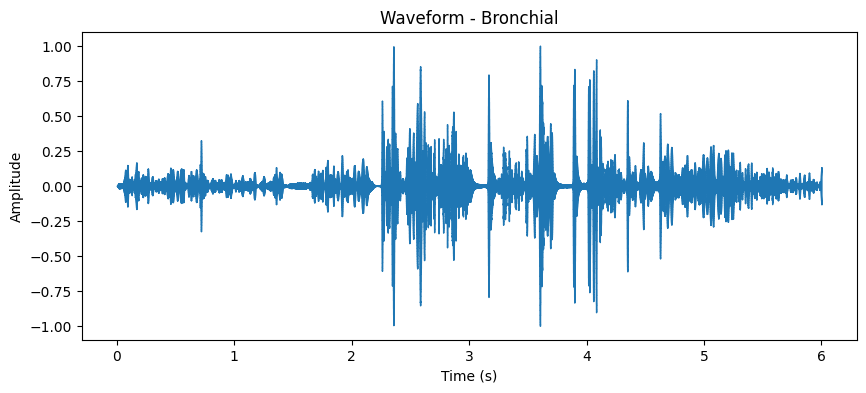

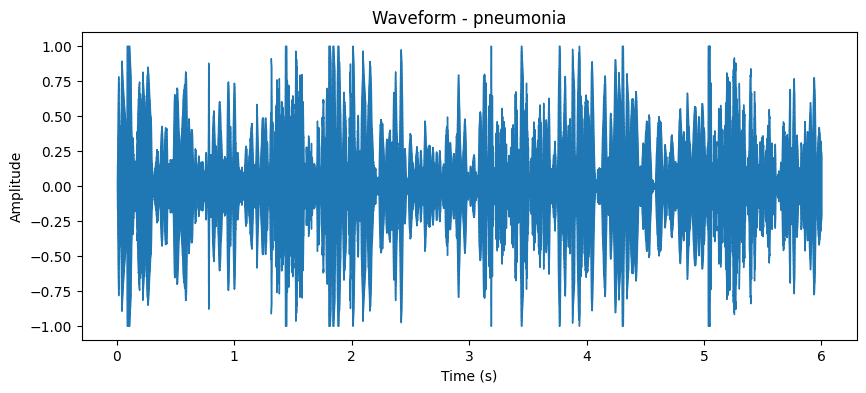

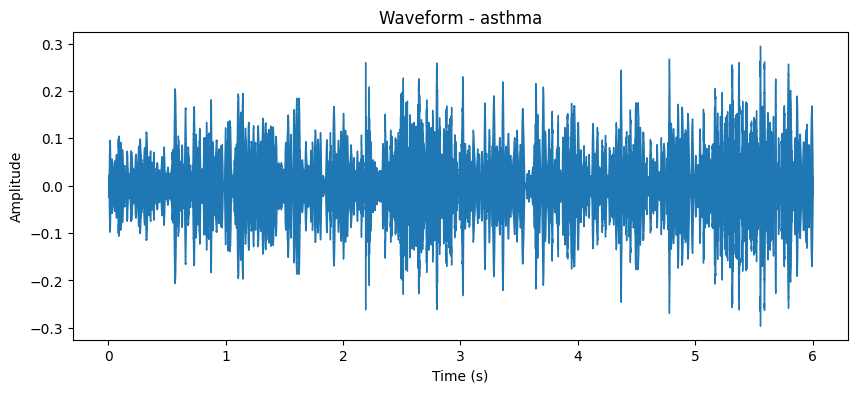

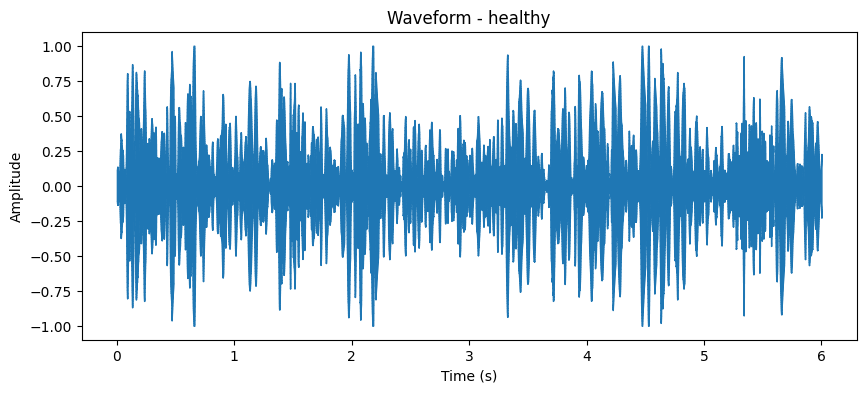

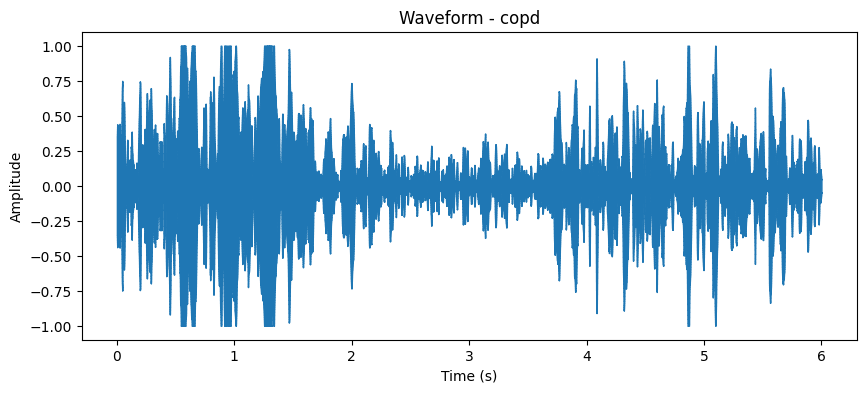

In [ ]:
##############################################################################
# 5) SHOW 5 WAVEFORM PLOTS (ONE FROM EACH CATEGORY)
##############################################################################
# The user wants exactly 5 waveforms, one for each category.
# We will loop through the 5 categories, load the first audio in each folder,
# and plot the waveform using librosa.display.waveshow.
print("\n=== Waveform Examples for Each Category ===")
for i, category in enumerate(categories):
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    if i < 5:  # just making sure we match exactly 5 categories
        if audio_files:
            audio_path = os.path.join(category_path, audio_files[0])
            y, sr = librosa.load(audio_path, sr=None)

            plt.figure(figsize=(10, 4))
            librosa.display.waveshow(y, sr=sr)
            plt.title(f'Waveform - {category}')
            plt.xlabel('Time (s)')
            plt.ylabel('Amplitude')
            plt.show()

In [ ]:
##############################################################################
# Fix 1) Rename local augmentation functions to avoid confusion
##############################################################################
def my_add_noise(audio, noise_factor=0.005):
    """Add random noise to the audio signal."""
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

def my_time_stretch(audio, rate=1.0):
    """Time-stretch audio by a certain rate, using librosa's built-in function."""
    # Note: we explicitly call librosa.effects.time_stretch with y= and rate=
    return librosa.effects.time_stretch(y=audio, rate=rate)

def my_pitch_shift(audio, sr, n_steps=0):
    """Pitch-shift audio by n_steps semitones, using librosa's built-in function."""
    return librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=n_steps)

def augment_audio(y, sr):
    """
    Randomly apply one or more transformations to the audio
    to improve dataset variability.
    """
    import random
    choice = random.choice(['noise', 'stretch', 'pitch', 'none'])

    if choice == 'noise':
        return my_add_noise(y)
    elif choice == 'stretch':
        rate = random.uniform(0.8, 1.2)   # random stretch factor
        return my_time_stretch(y, rate=rate)
    elif choice == 'pitch':
        steps = random.uniform(-2, 2)     # random pitch shift in semitones
        return my_pitch_shift(y, sr, n_steps=steps)
    else:
        return y  # no augmentation


In [ ]:
#############################################################################
# NEW: DATA AUGMENTATION + HANDLING CLASS IMBALANCE
# We'll find the largest category count and oversample the others by
# generating augmented audio until each category matches the largest count.
##############################################################################
print("\n=== Data Augmentation and Class Balancing ===")
max_count = max(category_counts.values())

all_audio_data = []   # Will store (audio_array, sr, label)
for category in categories:
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    current_count = len(audio_files)

    # Load original audio
    loaded_signals = []
    for audio_file in audio_files:
        audio_path = os.path.join(category_path, audio_file)
        y_load, sr_load = librosa.load(audio_path, sr=None)
        loaded_signals.append((y_load, sr_load))
        all_audio_data.append((y_load, sr_load, category))

    # If category is underrepresented, generate augmented samples
    if current_count < max_count:
        needed = max_count - current_count
        # Randomly augment from existing signals
        for _ in range(needed):
            # pick a random original signal
            orig_y, orig_sr = random.choice(loaded_signals)
            # apply augmentation
            y_aug = augment_audio(orig_y, orig_sr)
            all_audio_data.append((y_aug, orig_sr, category))

# Now we have an augmented list "all_audio_data"
# with all categories having the same number of samples.


=== Data Augmentation and Class Balancing ===


In [ ]:
!pip install pyloudnorm

In [ ]:
import pyloudnorm as pyln

In [ ]:
##############################################################################
# NEW: APPLY EBU R128 LOUDNESS NORMALIZATION
##############################################################################
print("\n=== Applying EBU R128 Normalization ===")

normalized_audio_data = []

target_lufs = -23.0  # you can change to -20 or -16 if needed

for y, sr, label in all_audio_data:
    # Ensure float64 (required)
    y = y.astype(np.float64)

    # Create loudness meter
    meter = pyln.Meter(sr)

    try:
        # Measure loudness
        loudness = meter.integrated_loudness(y)

        # Normalize
        y_norm = pyln.normalize.loudness(y, loudness, target_lufs)

        # Prevent clipping
        peak = np.max(np.abs(y_norm))
        if peak > 1.0:
            y_norm = y_norm / peak

    except Exception as e:
        # In case of very short or problematic audio
        print("Skipping normalization due to error:", e)
        y_norm = y

    normalized_audio_data.append((y_norm, sr, label))


=== Applying EBU R128 Normalization ===


/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possib

In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

def save_spectrogram(y, sr, save_path):
    plt.figure(figsize=(3, 3))

    # Create Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)

    # Convert to log scale (dB)
    S_dB = librosa.power_to_db(S, ref=np.max)

    # Plot without axes (important for ViT)
    librosa.display.specshow(S_dB, sr=sr)
    plt.axis('off')

    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close()

In [ ]:
spectrogram_dir = "/content/spectrograms"
os.makedirs(spectrogram_dir, exist_ok=True)

image_paths = []
labels = []

for i, (y, sr, label) in enumerate(normalized_audio_data):
    label_dir = os.path.join(spectrogram_dir, label)
    os.makedirs(label_dir, exist_ok=True)

    img_path = os.path.join(label_dir, f"spec_{i}.png")

    save_spectrogram(y, sr, img_path)

    image_paths.append(img_path)
    labels.append(label)

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1920
  warnings.warn(


In [ ]:
!pip install timm

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

class SpectrogramDataset(Dataset):
    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = labels

        self.label_to_idx = {label: i for i, label in enumerate(set(labels))}

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),  # ViT input size
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = self.transform(img)

        label = self.label_to_idx[self.labels[idx]]
        return img, label

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

# 80% train, 20% test
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

# Create datasets
train_dataset = SpectrogramDataset(train_paths, train_labels)
test_dataset = SpectrogramDataset(test_paths, test_labels)

# DataLoaders
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
import timm
import torch.nn as nn

num_classes = len(set(labels))

model = timm.create_model('vit_base_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, num_classes)

In [ ]:
from torch.utils.data import DataLoader

dataset = SpectrogramDataset(image_paths, labels)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 25

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    # Optional: evaluate on test set each epoch
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()

    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%\n")
    model.train()  # back to training mode

In [ ]:
##############################################################################
# 18) FEATURE EXTRACTION FOR MODEL TRAINING (MFCC MEAN FEATURES)
##############################################################################
# We'll now extract features for the classification model.
"""print("\n=== Preparing Features and Labels for Model ===")
feature_list = []
labels_list = []

for category in categories:
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    for audio_file in audio_files:
        audio_path = os.path.join(category_path, audio_file)
        y_data, sr_data = librosa.load(audio_path, sr=None)
        # Extract MFCC (13)
        mfcc_data = librosa.feature.mfcc(y=y_data, sr=sr_data, n_mfcc=13)
        # Take mean across time frames
        feature_list.append(np.mean(mfcc_data, axis=1))
        labels_list.append(category)

X = np.array(feature_list)
y = np.array(labels_list)

print("Total Samples:", len(feature_list))
print("Feature Shape:", X.shape)
##############################################################################
# 18) FEATURE EXTRACTION FOR MODEL TRAINING (MFCC + DELTA FEATURES)
##############################################################################

print("\n=== Preparing Features and Labels for Model ===")

feature_list = []
labels_list = []

for category in categories:
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]

    for audio_file in audio_files:
        audio_path = os.path.join(category_path, audio_file)

        # Load audio
        y_data, sr_data = librosa.load(audio_path, sr=None)

        # Extract MFCC
        mfcc_data = librosa.feature.mfcc(y=y_data, sr=sr_data, n_mfcc=13)

        n_frames = mfcc_data.shape[1]
        desired_width = 5

        # Adjust desired_width to be at most n_frames
        width = min(desired_width, n_frames)

        # Ensure width is odd. If it's even, subtract 1.
        if width % 2 == 0:
            width -= 1

        # Ensure minimum width of 1
        if width < 1:
            width = 1

        delta = librosa.feature.delta(mfcc_data, width=width)
        delta2 = librosa.feature.delta(mfcc_data, order=2, width=width)

        # Combine features (mean)
        features = np.concatenate([
            np.mean(mfcc_data, axis=1),
            np.mean(delta, axis=1),
            np.mean(delta2, axis=1)
        ])

        # Store features and labels
        feature_list.append(features)
        labels_list.append(category)

# Convert to numpy arrays
X = np.array(feature_list)
y = np.array(labels_list)

print("Total Samples:", len(feature_list))
print("Feature Shape:", X.shape)
"""

In [ ]:
##############################################################################
# 19) LABEL ENCODING
##############################################################################
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print("Labels Shape:", y_encoded.shape)

In [ ]:
##############################################################################
# 20) TRAIN-TEST SPLIT (80/20) AS REQUESTED
##############################################################################
# We will specifically do 80/20, as per your preference (test_size=0.2).
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

In [ ]:
##############################################################################
# 21) RESHAPE FOR LSTM (SAMPLES, TIMESTEPS, 1)
##############################################################################
# LSTM expects 3D input: (batch_size, timesteps, channels).
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
##############################################################################
# 22) BUILD AND COMPILE THE LSTM MODEL (RETENTION OF ORIGINAL STRUCTURE)
##############################################################################
model = Sequential()

model.add(
    Conv1D(
        filters=32, kernel_size=3, activation='relu',
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(
    Conv1D(
        filters=64, kernel_size=3, activation='relu',
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(y_encoded)), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

In [ ]:
##############################################################################
# 23) TRAIN THE MODEL (SHOW TRAINING & VALIDATION ACCURACY)
##############################################################################
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

# Test verisi üzerinde tahmin yap
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Metrikleri hesapla
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Sonuçları yazdır
print("\nModel Performans Metrikleri:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detaylı sınıflandırma raporu
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix için
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix oluştur
cm = confusion_matrix(y_test, y_pred_classes)

# Confusion Matrix'i görselleştir
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Eğitim sürecindeki accuracy ve loss değerlerinin grafiğini çiz
plt.figure(figsize=(12, 4))

# Accuracy grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Accuracy')
plt.plot(history.history['val_accuracy'], label='Doğrulama Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Loss')
plt.plot(history.history['val_loss'], label='Doğrulama Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

def plot_roc_curves(y_test, y_pred_proba):
    """
    Çok sınıflı ROC eğrilerini çizer

    Parametreler:
    y_test: Gerçek etiketler
    y_pred_proba: Model tahmin olasılıkları
    """

    # Sınıf sayısını belirle
    n_classes = y_pred_proba.shape[1]

    # Her sınıf için ROC eğrisi
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # One-hot encoding yap
    y_test_bin = np.eye(n_classes)[y_test]

    # Her sınıf için ROC eğrisi hesapla
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Ortalama ROC eğrisi hesapla
    fpr_mean = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    tpr_mean = np.zeros_like(fpr_mean)
    for i in range(n_classes):
        tpr_mean += np.interp(fpr_mean, fpr[i], tpr[i])
    tpr_mean = tpr_mean / n_classes

    fpr["macro"] = fpr_mean
    tpr["macro"] = tpr_mean
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # ROC eğrilerini çiz
    plt.figure(figsize=(10, 8))

    # Her sınıf için ROC eğrisi
    colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'Sınıf {i} (AUC = {roc_auc[i]:.2f})')

    # Ortalama ROC eğrisi
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Ortalama ROC (AUC = {roc_auc["macro"]:.2f})',
             color='navy', linestyle=':', linewidth=4)

    # Referans çizgisi
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return roc_auc

# Model tahminlerini al
y_pred_proba = model.predict(X_test)

# ROC eğrilerini çiz ve AUC değerlerini al
roc_auc_scores = plot_roc_curves(y_test, y_pred_proba)

# AUC değerlerini yazdır
print("\nAUC Değerleri:")
for i in range(len(np.unique(y_test))):
    print(f"Sınıf {i}: {roc_auc_scores[i]:.4f}")
print(f"Ortalama AUC: {roc_auc_scores['macro']:.4f}")

In [ ]:
##############################################################################
# 21) RESHAPE FOR LSTM (SAMPLES, TIMESTEPS, 1)
##############################################################################
# LSTM expects 3D input: (batch_size, timesteps, channels).
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1])

In [ ]:
model = Sequential()

model.add(Conv1D(filters=32, kernel_size=3, activation='relu',
                 input_shape=(X_train.shape[1], 1), padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=2))

model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(y_encoded)), activation='softmax'))


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

In [ ]:
##############################################################################
# 23) TRAIN THE MODEL (SHOW TRAINING & VALIDATION ACCURACY)
##############################################################################
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

# Test verisi üzerinde tahmin yap
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Metrikleri hesapla
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Sonuçları yazdır
print("\nModel Performans Metrikleri:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detaylı sınıflandırma raporu
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix için
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix oluştur
cm = confusion_matrix(y_test, y_pred_classes)

# Confusion Matrix'i görselleştir
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Eğitim sürecindeki accuracy ve loss değerlerinin grafiğini çiz
plt.figure(figsize=(12, 4))

# Accuracy grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Accuracy')
plt.plot(history.history['val_accuracy'], label='Doğrulama Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Loss')
plt.plot(history.history['val_loss'], label='Doğrulama Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# sadece cnn kullanınca daha iyi sonuç verdi